## Классификация текстов с использованием предобученных языковых моделей.

В данном задании вам предстоит обратиться к задаче классификации текстов и решить ее с использованием предобученной модели BERT.

In [1]:
import json
# do not change the code in the block below
# __________start of block__________
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import clear_output
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

%matplotlib inline
# __________end of block__________

Обратимся к набору данных SST-2. Holdout часть данных (которая понадобится вам для посылки) доступна по ссылке ниже.

In [2]:
# do not change the code in the block below
# __________start of block__________

!wget https://raw.githubusercontent.com/girafe-ai/ml-course/refs/heads/24f_yandex_ml_trainings/homeworks/hw04_bert_and_co/texts_holdout.json
# __________end of block__________

--2025-10-26 16:48:08--  https://raw.githubusercontent.com/girafe-ai/ml-course/refs/heads/24f_yandex_ml_trainings/homeworks/hw04_bert_and_co/texts_holdout.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 51581 (50K) [text/plain]
Saving to: ‘texts_holdout.json’

texts_holdout.json  100%[===================>]  50.37K  --.-KB/s    in 0.001s  

2025-10-26 16:48:08 (42.1 MB/s) - ‘texts_holdout.json’ saved [51581/51581]



In [3]:
# do not change the code in the block below
# __________start of block__________
df = pd.read_csv(
    "https://github.com/clairett/pytorch-sentiment-classification/raw/master/data/SST2/train.tsv",
    delimiter="\t",
    header=None,
)
texts_train = df[0].values[:5000]
y_train = df[1].values[:5000]
texts_test = df[0].values[5000:]
y_test = df[1].values[5000:]
with open("texts_holdout.json") as iofile:
    texts_holdout = json.load(iofile)
# __________end of block__________

Весь остальной код предстоит написать вам.

Для успешной сдачи на максимальный балл необходимо добиться хотя бы __84.5% accuracy на тестовой части выборки__.

In [5]:
# your beautiful experiments her
from transformers import DistilBertModel, DistilBertTokenizer, logging

In [7]:
logging.set_verbosity_error()

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
model = DistilBertModel.from_pretrained("distilbert-base-uncased")

text = "Text classification model bert base uncased"
encoded_input = tokenizer(text, return_tensors="pt")
with torch.no_grad():
    output = model(**encoded_input)

output.last_hidden_state.shape

torch.Size([1, 9, 768])

In [15]:
tokenized_text = tokenizer(text)
print(tokenized_text)
print(f"Tokens: {tokenizer.convert_ids_to_tokens(tokenized_text['input_ids'])}")
print(f"Decoded sequence: '{tokenizer.decode(tokenized_text['input_ids'])}'")

{'input_ids': [101, 3793, 5579, 2944, 14324, 2918, 4895, 28969, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}
Tokens: ['[CLS]', 'text', 'classification', 'model', 'bert', 'base', 'un', '##cased', '[SEP]']
Decoded sequence: '[CLS] text classification model bert base uncased [SEP]'


In [16]:
tokenized_texts_train = tokenizer(
    texts_train.tolist(),
    padding=True,
    truncation=True,
    max_length=512,
    return_tensors="pt",
)
tokenized_texts_test = tokenizer(
    texts_test.tolist(),
    padding=True,
    truncation=True,
    max_length=512,
    return_tensors="pt",
)

In [25]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

batch_size = 32
train_features = []
model.eval()
with torch.no_grad():
    for i in range(0, len(texts_train), batch_size):
        texts_batch = tokenized_texts_train["input_ids"][i : i + batch_size].to(device)
        masks_batch = tokenized_texts_train["attention_mask"][i : i + batch_size].to(device)

        output = model(texts_batch, masks_batch)
        train_features.append(output.last_hidden_state[:, 0, :].cpu())

train_features = torch.cat(train_features, dim=0)
train_features.shape

torch.Size([5000, 768])

In [33]:
batch_size = 32
test_features = []
model.eval()
with torch.no_grad():
    for i in range(0, len(texts_test), batch_size):
        texts_batch = tokenized_texts_test["input_ids"][i : i + batch_size].to(device)
        masks_batch = tokenized_texts_test["attention_mask"][i : i + batch_size].to(device)

        output = model(texts_batch, masks_batch)
        test_features.append(output.last_hidden_state[:, 0, :].cpu())

test_features = torch.cat(test_features, dim=0)
test_features.shape

torch.Size([1920, 768])

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

In [28]:
import warnings
warnings.simplefilter("ignore")
classifier = LogisticRegression().fit(train_features, y_train)

In [34]:
print(classifier.score(train_features, y_train), classifier.score(test_features, y_test))

0.8842 0.8453125


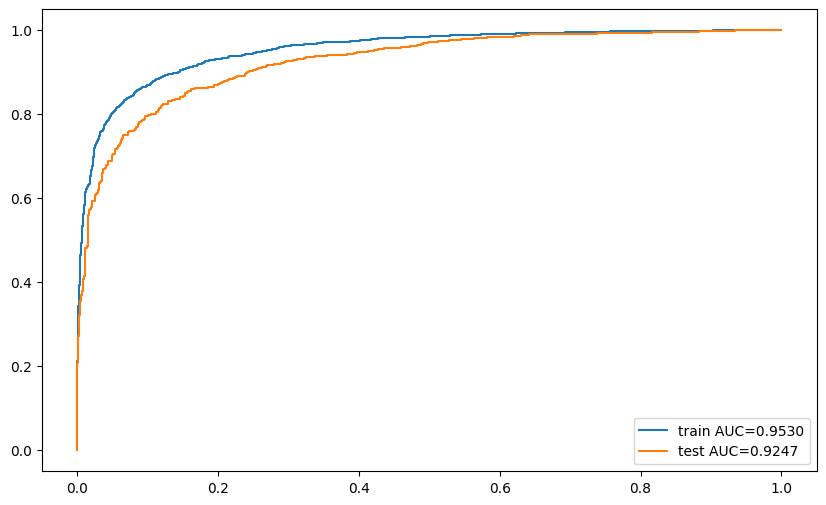

In [36]:
plt.figure(figsize=(10, 6))

proba = classifier.predict_proba(train_features)[:, 1]
auc = roc_auc_score(y_train, proba)
plt.plot(*roc_curve(y_train, proba)[:2], label=f"train AUC={auc:.4f}")

proba = classifier.predict_proba(test_features)[:, 1]
auc = roc_auc_score(y_test, proba)
plt.plot(*roc_curve(y_test, proba)[:2], label=f"test AUC={auc:.4f}")

plt.legend()
plt.show()

#### Сдача взадания в контест
Сохраните в словарь `out_dict` вероятности принадлежности к первому (положительному) классу

In [49]:
out_dict = {
    'train': classifier.predict_proba(train_features)[:, 1].tolist(), # list of length 5000 with probas
    'test': classifier.predict_proba(test_features)[:, 1].tolist(),  # list of length 1920 with probas
    # 'holdout': classifier,  # list of length 500 with probas
}

Несколько `assert`'ов для проверки вашей посылки:

In [50]:
assert isinstance(out_dict["train"], list), "Object must be a list of floats"
assert isinstance(out_dict["train"][0], float), "Object must be a list of floats"
assert (
    len(out_dict["train"]) == 5000
), "The predicted probas list length does not match the train set size"

assert isinstance(out_dict["test"], list), "Object must be a list of floats"
assert isinstance(out_dict["test"][0], float), "Object must be a list of floats"
assert (
    len(out_dict["test"]) == 1920
), "The predicted probas list length does not match the test set size"

# assert isinstance(out_dict["holdout"], list), "Object must be a list of floats"
# assert isinstance(out_dict["holdout"][0], float), "Object must be a list of floats"
# assert len(
#     out_dict["holdout"] == 500
# ), "The predicted probas list length does not match the holdout set size"

Запустите код ниже для генерации посылки.

In [ ]:
# do not change the code in the block below
# __________start of block__________
FILENAME = "submission_dict_hw_text_classification_with_bert.json"

with open(FILENAME, "w") as iofile:
    json.dump(out_dict, iofile)
print(f"File saved to `{FILENAME}`")
# __________end of block__________

На этом задание завершено. Поздравляем!